## Credit Risk Prediction (Classification)

# i. Imports


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print('Libraries imported successfully.')


Libraries imported successfully.


# ii. Load & Inspect

In [20]:
df = pd.read_csv('train.csv')

print(f'Shape: {df.shape}')
print()
print(df.head())


Shape: (614, 13)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2 

# iii. Checking Missing Values

In [21]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


# iv. Fixing Missing Values

In [22]:
# Numeric Columns, fill missing values with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

# Categorical Columns, fill missing values with most common value
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after fix:')
print(df.isnull().sum())

Missing values after fix:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# v. Loan Approval Count Plot

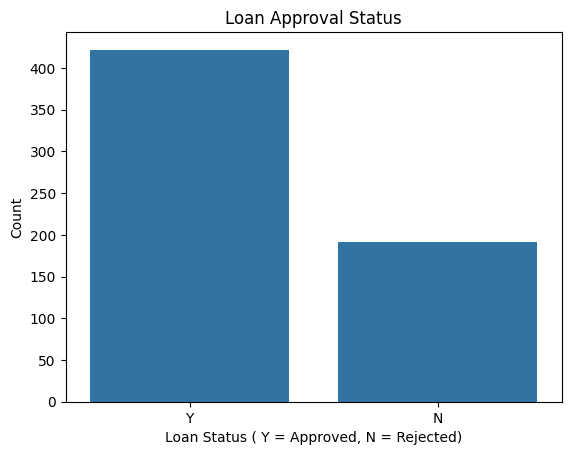

In [23]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval Status')
plt.xlabel('Loan Status ( Y = Approved, N = Rejected)')
plt.ylabel('Count')
plt.savefig('loan_status.png')
plt.show()

# vi. Credit History vs Loan Status

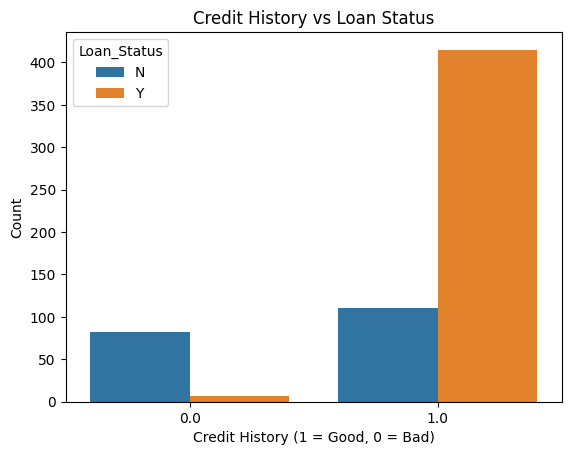

In [24]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.xlabel('Credit History (1 = Good, 0 = Bad)')
plt.ylabel('Count')
plt.savefig('credit_history_vs_status.png')
plt.show()

# vii. Income vs Loan Status

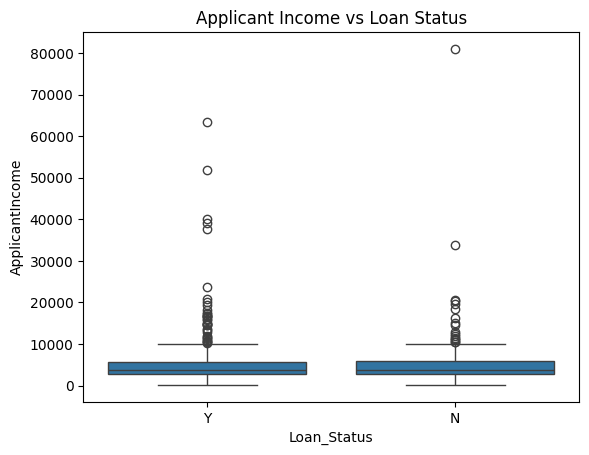

In [25]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Applicant Income vs Loan Status')
plt.savefig('income_vs_status.png')
plt.show()

# viii. Encode & Drop ID

In [26]:
df = df.drop('Loan_ID', axis=1)

le = LabelEncoder()
for col in df.select_dtypes(include='str').columns:
    df[col] = le.fit_transform(df[col])



print('Encoded DataFrame:')
print(df.head())

Encoded DataFrame:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            0  
2

# ix. Train the model

In [27]:
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

print('Model Trained')



Model Trained


# x.  Evaluation

Accuracy:  69.11%


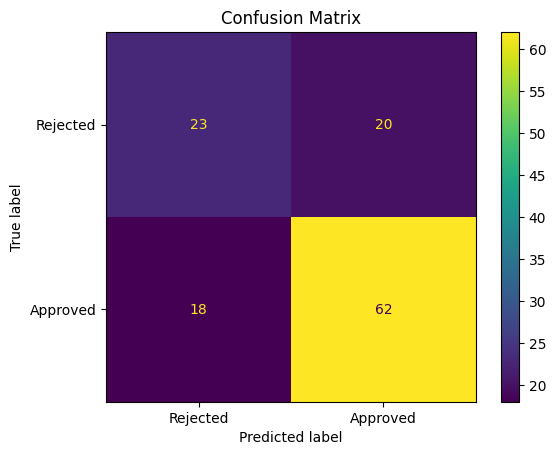

In [28]:
y_pred = model.predict(x_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred): .2%}')


ConfusionMatrixDisplay(confusion_matrix
                (y_test, y_pred), display_labels=['Rejected', 'Approved']).plot()
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()